In [1]:
from pathlib import Path

import pandas as pd
from ucimlrepo import fetch_ucirepo

if "__file__" in globals():
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
else:
    PROJECT_ROOT = Path.cwd().parent  # adjust if your notebook is elsewhere

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

ds = fetch_ucirepo(id=601)

df = ds.data.features.copy()
df["Machine failure"] = ds.data.targets["Machine failure"]

output_path = RAW_DATA_DIR / "ai4i2020_raw.csv"
df.to_csv(output_path, index=False)

print(f"Saved {df.shape} to {output_path}")

Saved (10000, 7) to c:\Users\PC\Development\python projects\predictive-maintenance-ai4i\data\raw\ai4i2020_raw.csv


In [2]:
df.info()
df.describe()
df.isna().sum()
df.duplicated().sum()
df["Machine failure"].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  str    
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
dtypes: float64(3), int64(3), str(1)
memory usage: 547.0 KB


Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [3]:
# We removed them at the start, this step is not neccessary now

# fail_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
# leak_check = (df[fail_cols].sum(axis=1)>0)
# print((leak_check == df["Machine failure"].astype(bool)).mean())

In [4]:
import seaborn as sns

<Axes: xlabel='Machine failure', ylabel='Torque'>

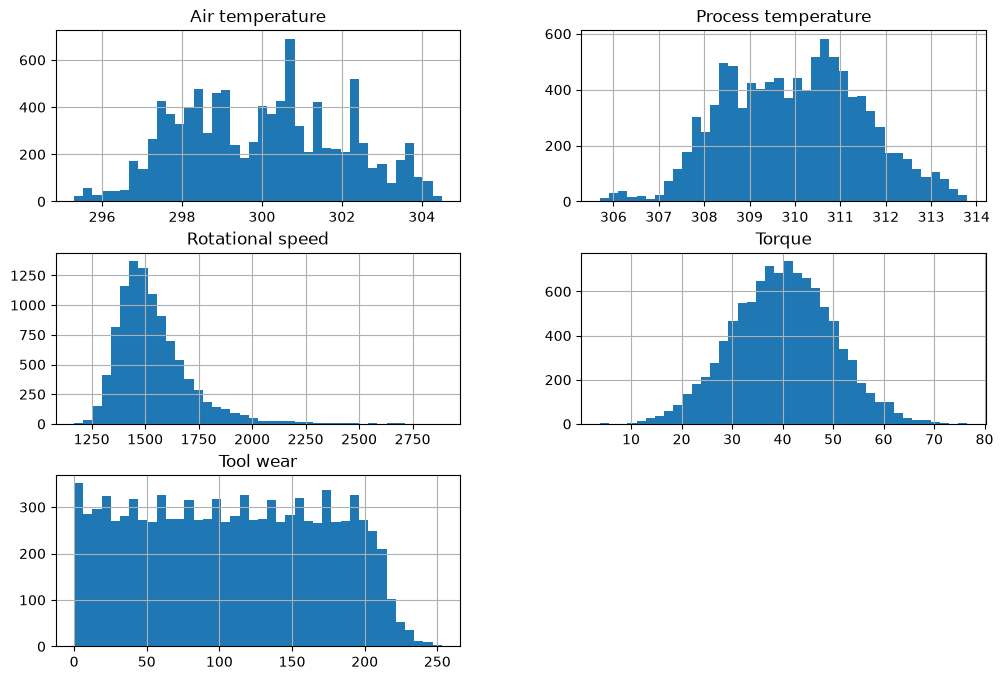

In [5]:
num_cols = ["Air temperature", "Process temperature", "Rotational speed", "Torque", "Tool wear"]
df[num_cols].hist(bins=40, figsize=(12,8))

sns.boxplot(data=df, x="Machine failure", y="Torque")
sns.boxplot(data=df, x="Machine failure", y= "Tool wear")

**count machine failure**

In [6]:
count = df["Machine failure"].sum()
print(f"Machine failures count: {count}")

Machine failures count: 339


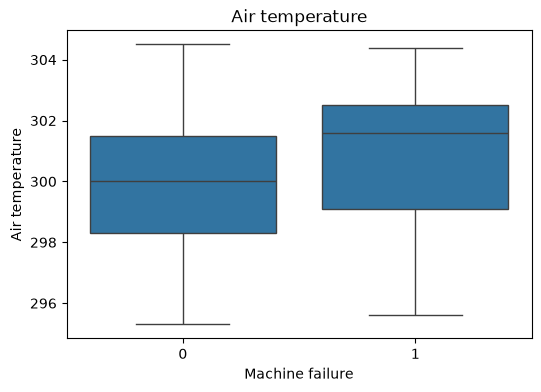

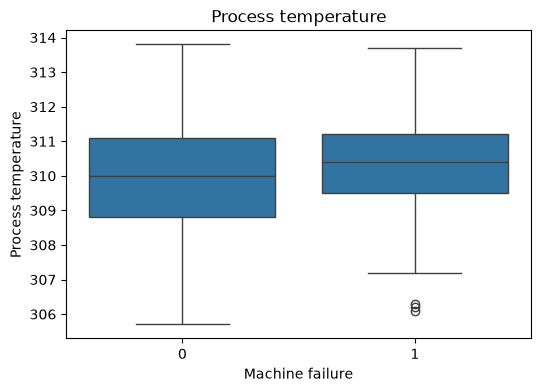

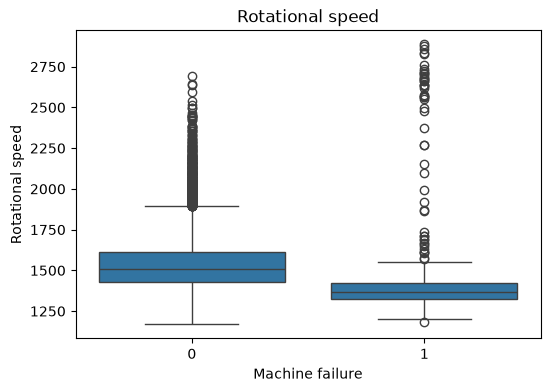

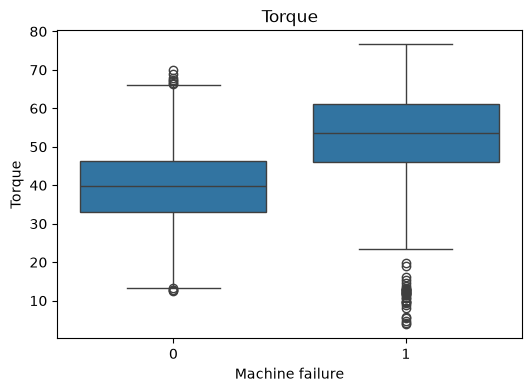

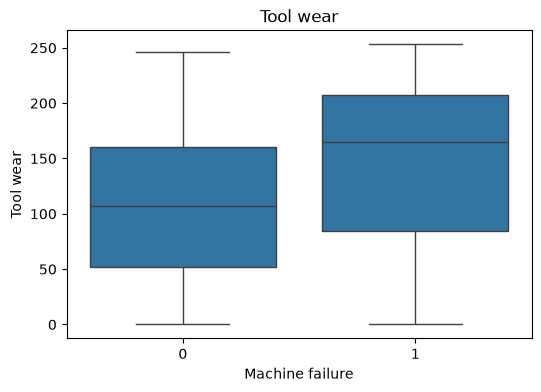

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="Machine failure", y=col)
    plt.title(col)
    plt.show()

**لـ Box Plot يبين ارتباطًا، لا يثبت السببية**

النمط الأكثر شيوعًا بين حالات الفشل هو Torque أعلى وRotational speed أقل، مع وجود حالات فشل متطرفة تظهر النمط المعاكس.

Torque: حالات الفشل تميل إلى عزم أعلى، لكن يوجد أيضًا جزء من حالات الفشل عند عزم منخفض جدًا. إذن العلاقة ليست ببساطة: كلما زاد العزم زاد الفشل.
Rotational speed: حالات الفشل تميل غالبًا إلى سرعة أقل، مع وجود حالات عند سرعات مرتفعة جدًا أيضًا.
وهذا منطقي مع العلاقة الفيزيائية التي ذكرها الدليل: Torque وRotational speed يتحركان غالبًا عكسيًا عند قدرة شبه ثابتة؛ ارتفاع أحدهما يصاحبه عادة انخفاض الآخر.
Tool wear: حالات الفشل تظهر أكثر عند قيم تآكل أعلى. لكن الأفضل أن تقول "مرتبط بالفشل" وليس "يزيد احتمال الفشل"؛ لأن الـBox Plot يبين ارتباطًا، لا يثبت السببية.
Air temperature: إذا كان صندوق الفشل أعلى فعلًا في رسمك، فنستنتج أن حالات الفشل تميل إلى حرارة هواء أعلى.
Process temperature: نفس الفكرة، لكن يبدو أن الفرق أضعف من Torque وTool wear.

In [8]:
df.groupby("Machine failure")[num_cols].agg(
    ["min", "max", "mean", "median", "std"]
)

Air temperature                                      \
                            min    max        mean median       std   
Machine failure                                                       
0                         295.3  304.5  299.973999  300.0  1.990748   
1                         295.6  304.4  300.886431  301.6  2.071473   

                Process temperature                                      ...  \
                                min    max        mean median       std  ...   
Machine failure                                                          ...   
0                             305.7  313.8  309.995570  310.0  1.486846  ...   
1                             306.1  313.7  310.290265  310.4  1.363686  ...   

                Torque                                    Tool wear       \
                   min   max       mean median        std       min  max   
Machine failure                                                            
0                 12.6  70.0  39.629655   39.9   9.472080         0  246   
1                  3.8  76.6  50.168142   53.7  16.374498         0  253   

                                               
                       mean median        std  
Machine failure                                
0                106.693717  107.0  62.945790  
1                143.781711  165.0  72.759876  

[2 rows x 25 columns]

In [9]:
df.groupby("Machine failure")[num_cols].quantile(
    [0.05, 0.25, 0.50, 0.75, 0.95]
)

Air temperature  Process temperature  Rotational speed  \
Machine failure                                                                
0               0.05            297.1               307.70            1339.0   
                0.25            298.3               308.80            1429.0   
                0.50            300.0               310.00            1507.0   
                0.75            301.5               311.10            1615.0   
                0.95            303.5               312.50            1863.0   
1               0.05            297.2               307.90            1262.9   
                0.25            299.1               309.50            1326.5   
                0.50            301.6               310.40            1365.0   
                0.75            302.5               311.20            1421.5   
                0.95            303.5               312.21            2641.0   

                      Torque  Tool wear  
Machine failure                          
0               0.05   23.60        9.0  
                0.25   33.10       52.0  
                0.50   39.90      107.0  
                0.75   46.30      160.0  
                0.95   54.80      204.0  
1               0.05   12.09       14.7  
                0.25   45.95       84.5  
                0.50   53.70      165.0  
                0.75   61.20      207.5  
                0.95   69.40      228.0

Air temperature 0
Process temperature 0
Rotational speed 418
Torque 69
Tool wear 0


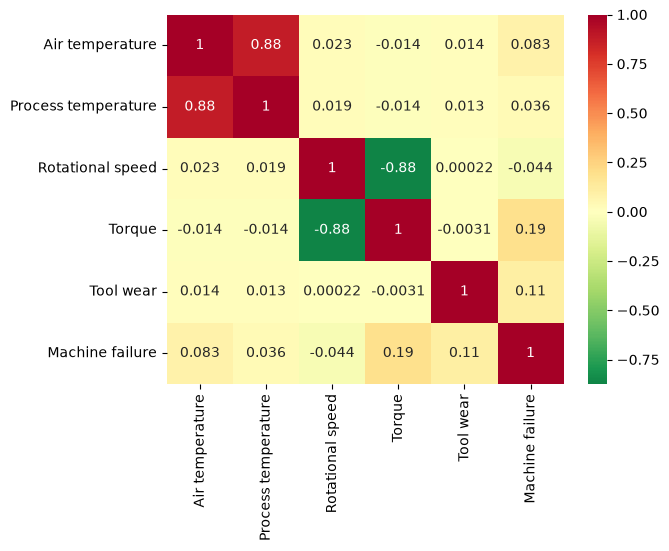

In [10]:
corr = df[num_cols + ["Machine failure"]].corr()
sns.heatmap(corr, annot=True, cmap="RdYlGn_r", center=0)
# لكل عمود عددي IQR القيم الشاذة عبر 
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    print(col, len(outliers))

In [11]:
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1

    outliers = df[
        (df[col] < q1 - 1.5 * iqr) |
        (df[col] > q3 + 1.5 * iqr)
    ]

    print(col, len(outliers))

Air temperature 0
Process temperature 0
Rotational speed 418
Torque 69
Tool wear 0


# One-Hot Encoding

Instead of having `Type` column, we replace it with two new columns `type_M` and `type_L`.
Now the shift will be like this:

| Type | type_M | type_L |
|---|---:|---:|
| L | 0 | 1 |
| M | 1 | 0 |
| H | 0 | 0 |


In [12]:
df = pd.get_dummies(
    df,
    columns=["Type"],
    prefix="type",
    drop_first=True
)

In [13]:
df.head()
df.columns

Index(['Air temperature', 'Process temperature', 'Rotational speed', 'Torque',
       'Tool wear', 'Machine failure', 'type_L', 'type_M'],
      dtype='str')

In [14]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Machine failure"]
)

print(train_df.shape)
print(test_df.shape)

print(train_df["Machine failure"].value_counts(normalize=True))
print(test_df["Machine failure"].value_counts(normalize=True))

(8000, 8)
(2000, 8)
Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


# Feature engineering

Power=Torque×Angular Speed

لأن Rotational speed عندنا بالدورات في الدقيقة، نحوله أولًا إلى rad/s.

In [15]:
import numpy as np

train_df["power_w"] = (
    train_df["Torque"] *
    (train_df["Rotational speed"] * 2 * np.pi / 60)
)

In [16]:
train_df[["Torque", "Rotational speed", "power_w"]].head()

,Torque,Rotational speed,power_w
4058,47.2,1456,7196.676675
1221,46.4,1399,6797.736296
6895,45.6,1357,6479.974671
9863,56.3,1411,8318.864043
8711,28.7,1733,5208.456932


فرق الحرارة:

In [17]:
train_df["temp_diff_k"] = (
    train_df["Process temperature"]
    - train_df["Air temperature"]
)

In [18]:
train_df[
    ["Air temperature", "Process temperature", "temp_diff_k"]
].head()

,Air temperature,Process temperature,temp_diff_k
4058,302.0,310.9,8.9
1221,297.0,308.3,11.3
6895,301.0,311.6,10.6
9863,298.9,309.8,10.9
8711,297.1,308.5,11.4


خاصية التفاعل بين التآكل والعزم:

In [19]:
train_df["wear_torque_interaction"] = (
    train_df["Tool wear"] * train_df["Torque"]
)

In [20]:
train_df[
    ["Tool wear", "Torque", "wear_torque_interaction"]
].head()

,Tool wear,Torque,wear_torque_interaction
4058,54,47.2,2548.8
1221,132,46.4,6124.8
6895,137,45.6,6247.2
9863,84,56.3,4729.2
8711,50,28.7,1435.0


In [29]:
# Simpler way to keep the engineered feature all in one function

def engineer_features(data):
    data = data.copy()

    data["power_w"] = (
        data["Torque"] *
        (data["Rotational speed"] * 2 * np.pi / 60)
    )

    data["temp_diff_k"] = (
        data["Process temperature"] - data["Air temperature"]
    )

    data["wear_torque_interaction"] = (
        data["Tool wear"] * data["Torque"]
    )

    return data

In [21]:
from sklearn.model_selection import train_test_split

train_part, val_part = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["Machine failure"]
)

print(train_part.shape)
print(val_part.shape)

print(train_part["Machine failure"].value_counts())
print(val_part["Machine failure"].value_counts())

(6400, 11)
(1600, 11)
Machine failure
0    6183
1     217
Name: count, dtype: int64
Machine failure
0    1546
1      54
Name: count, dtype: int64


# Logistic Regression Baseline Model

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score

feature_cols = [
    col for col in train_part.columns
    if col != "Machine failure"
]

X_train = train_part[feature_cols]
y_train = train_part["Machine failure"]

X_val = val_part[feature_cols]
y_val = val_part["Machine failure"]

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Air temperature','Process temperature','Rotational speed',...,'power_w', 'temp_diff_k','wear_torque_interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [23]:
y_pred = baseline.predict(X_val)
y_score = baseline.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred, digits=3))
print("Average Precision:", average_precision_score(y_val, y_score))

              precision    recall  f1-score   support

           0      0.993     0.841     0.911      1546
           1      0.155     0.833     0.261        54

    accuracy                          0.841      1600
   macro avg      0.574     0.837     0.586      1600
weighted avg      0.965     0.841     0.889      1600

Average Precision: 0.46757539915424845


# XGBoost مع Stratified Cross-Validation.

In [24]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

search = GridSearchCV(
    xgb,
    param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(search.best_params_)
print("Best CV Average Precision:", search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV Average Precision: 0.8880369461427524


المقارنة العادلة: XGBoost وBaseline على نفس val_part

In [25]:
from sklearn.metrics import classification_report, average_precision_score

best_xgb = search.best_estimator_

y_val_pred = best_xgb.predict(X_val)
y_val_score = best_xgb.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_val_pred, digits=3))
print(
    "Validation Average Precision:",
    average_precision_score(y_val, y_val_score)
)

              precision    recall  f1-score   support

           0      0.993     0.986     0.989      1546
           1      0.662     0.796     0.723        54

    accuracy                          0.979      1600
   macro avg      0.827     0.891     0.856      1600
weighted avg      0.982     0.979     0.980      1600

Validation Average Precision: 0.8430473120500354


Threshold Tuning على val_part

In [26]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_score
)

for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
    if r >= 0.90:
        print(
            f"Threshold: {t:.3f} | "
            f"Precision: {p:.3f} | "
            f"Recall: {r:.3f}"
        )

Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0.000 | Precision: 0.034 | Recall: 1.000
Threshold: 0

In [27]:
import numpy as np

valid = recall[:-1] >= 0.90

best_idx = np.argmax(precision[:-1][valid])

best_threshold = thresholds[valid][best_idx]
best_precision = precision[:-1][valid][best_idx]
best_recall = recall[:-1][valid][best_idx]

print("Best threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)

Best threshold: 0.15371445
Precision: 0.35251798561151076
Recall: 0.9074074074074074


اختيار Recall >= 0.90 كان هدفًا افتراضيًا للتجربة، وليس رقمًا مقدسًا أو مستخرجًا من البيانات. في مشروع حقيقي، يجب تحديده بناءً على تكلفة missed failure مقابل false alarm.
- إذا كان تفويت العطل مكلفًا جدًا → Recall = 90% قد يكون منطقيًا.
- إذا كانت الإنذارات الكاذبة مكلفة جدًا → ربما 90% Recall ليس أفضل نقطة تشغيل.

# Testing with the test data

In [30]:
test_final = engineer_features(test_df)

X_test = test_final[feature_cols]
y_test = test_final["Machine failure"]

In [31]:
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    confusion_matrix
)

y_test_score = best_xgb.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_score >= best_threshold
).astype(int)

print(classification_report(
    y_test,
    y_test_pred,
    digits=3
))

print(
    "Test Average Precision:",
    average_precision_score(y_test, y_test_score)
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

           0      0.996     0.947     0.971      1932
           1      0.374     0.897     0.528        68

    accuracy                          0.946      2000
   macro avg      0.685     0.922     0.750      2000
weighted avg      0.975     0.946     0.956      2000

Test Average Precision: 0.848892694118384
Confusion Matrix:
[[1830  102]
 [   7   61]]
